In [1]:
!pip install optuna

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, Ridge, Lasso LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set(style='whitegrid')
%matplotlib inline

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set(style='whitegrid')
%matplotlib inline

In [3]:
TARGET_COL   = 'latitude'

df = pd.read_csv("country_metadata.csv")
print(f'Shape: {df.shape}')
df.head()

Shape: (217, 7)


,country_code,country_name,iso3,region,income_group,latitude,longitude
0,ABW,Aruba,ABW,Latin America & Caribbean,High income,12.51670,-70.0167
1,AFG,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income,34.52280,69.1761
2,AGO,Angola,AGO,Sub-Saharan Africa,Lower middle income,-8.81155,13.2420
3,ALB,Albania,ALB,Europe & Central Asia,Upper middle income,41.33170,19.8172
4,AND,Andorra,AND,Europe & Central Asia,High income,42.50750,1.5218


In [4]:
df.describe()

,latitude,longitude
count,211.000000,211.000000
mean,18.889009,19.139549
std,24.210877,70.391069
min,-41.286500,-175.216000
25%,4.392035,-14.440200
50%,17.300000,19.259500
75%,39.882400,50.214300
max,64.183600,179.089567


In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_%': missing_pct
}).sort_values('missing_%', ascending=False)

missing_df = missing_df[missing_df['missing_count'] > 0]

print(f'Столбцов с пропусками: {len(missing_df)}')
display(missing_df)

Столбцов с пропусками: 2


,missing_count,missing_%
longitude,6,2.76
latitude,6,2.76


In [6]:
df = df.dropna()

In [7]:
df.describe()
print(f'Shape: {df.shape}')

Shape: (211, 7)


In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Числовых столбцов: {len(num_cols)}')
print(f'Категориальных столбцов: {len(cat_cols)}')

Числовых столбцов: 2
Категориальных столбцов: 5


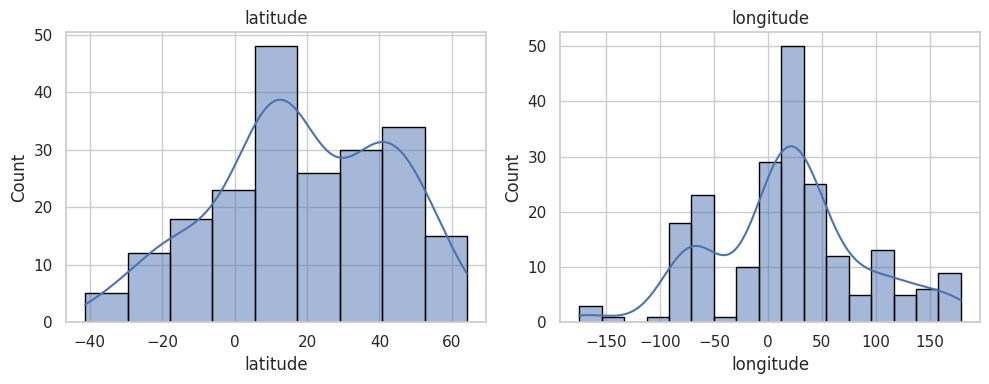

In [9]:
# ===== СТОЛБЦЫ ДЛЯ ГРАФИКОВ =====
PLOT_COLS = num_cols   # все числовые (измени список при необходимости)
# =================================

# Гистограммы с KDE
n = len(PLOT_COLS)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(5 * cols_per_row, 4 * rows))
axes = np.array(axes).flatten()

for i, col in enumerate(PLOT_COLS):
    sns.histplot(df[col], kde=True, ax=axes[i], edgecolor='black')
    axes[i].set_title(col)

# Скрываем пустые оси
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

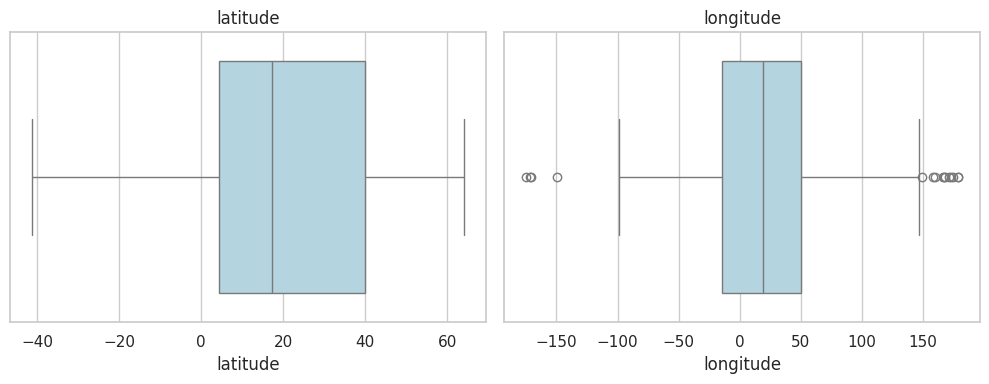

In [10]:
fig, axes = plt.subplots(rows, cols_per_row, figsize=(5 * cols_per_row, 4 * rows))
axes = np.array(axes).flatten()

for i, col in enumerate(PLOT_COLS):
    sns.boxplot(x=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

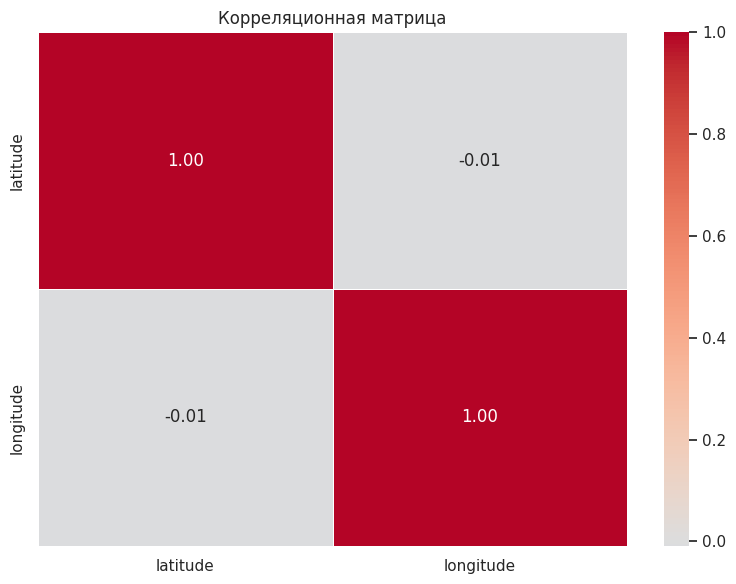

In [11]:
corr = df[PLOT_COLS].corr()

plt.figure(figsize=(max(8, len(PLOT_COLS) * 0.7),
              max(6, len(PLOT_COLS) * 0.6)))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

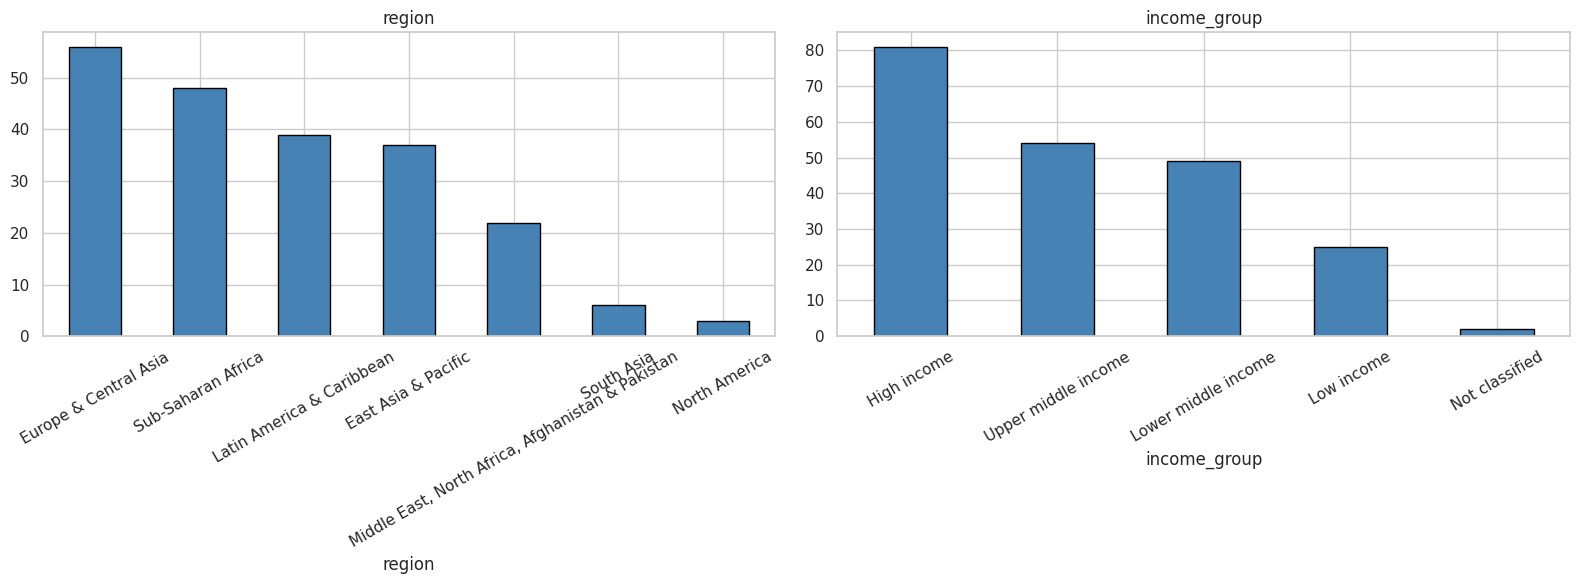

In [12]:
cat_cols_d = df[['region', 'income_group']]
n_cat_d = 2
fig, axes = plt.subplots(1, n_cat_d, figsize=(16, 6))
if n_cat_d == 1:
    axes = [axes]
for ax, col in zip(axes, cat_cols_d):
    vc = df[col].value_counts()
    # Если уникальных значений много — показываем топ-10
    if len(vc) > 10:
        vc = vc.head(10)
        ax.set_title(f'{col} (top 10)')
    else:
        ax.set_title(col)
    vc.plot.bar(ax=ax, edgecolor='black', color='steelblue')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

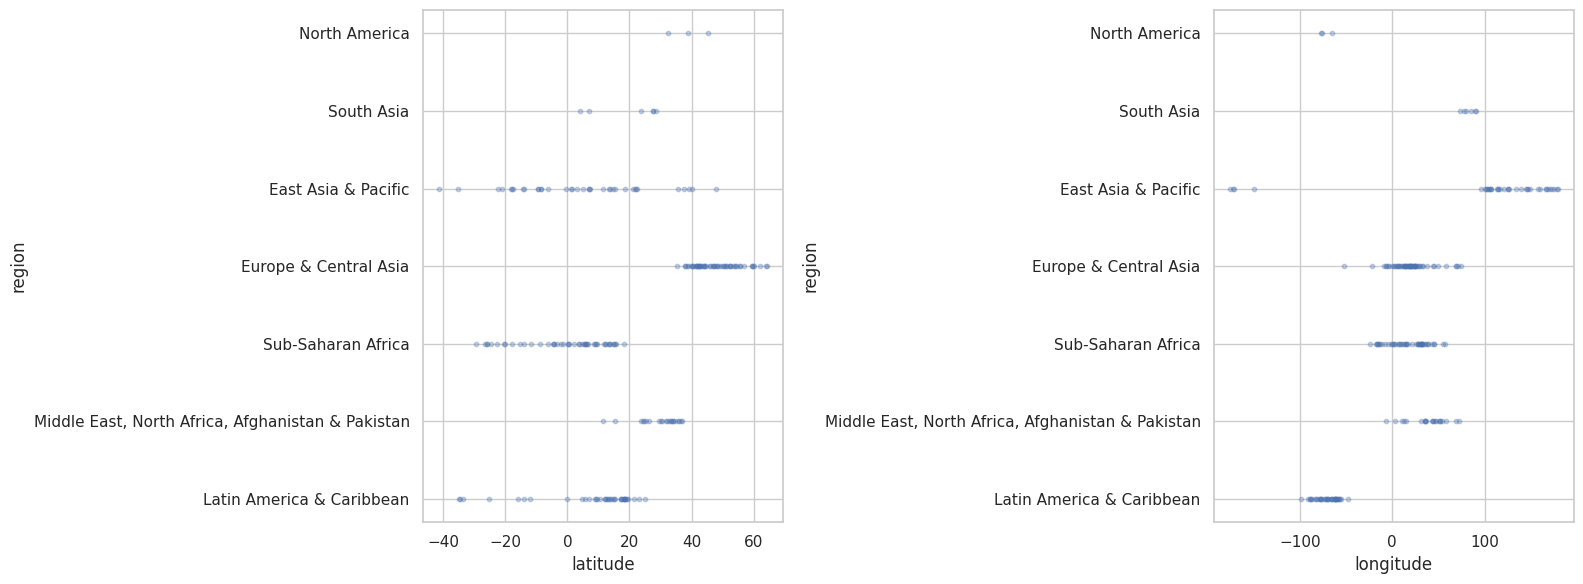

In [13]:
TARGET_COL = 'region'

if TARGET_COL is None or TARGET_COL not in df.columns:
    print('TARGET_COL не задан или не найден — пропускаем scatter vs target.')
else:
    scatter_cols = [c for c in PLOT_COLS if c != TARGET_COL][:2]
    if len(scatter_cols) == 0:
        print('Нет числовых признаков для scatter.')
    else:
        fig, axes = plt.subplots(1, len(scatter_cols),
                                figsize=(16, 6))
        if len(scatter_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, scatter_cols):
            ax.scatter(df[col], df[TARGET_COL], alpha=0.3, s=10)
            ax.set_xlabel(col)
            ax.set_ylabel(TARGET_COL)
        plt.tight_layout()
        plt.show()

In [14]:
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'non-null': df.notnull().sum(),
    'unique': df.nunique(),
    'mean/median': [round(df[c].median(), 4) if c in num_cols else '-' for c in df.columns],
    'mode': [df[c].mode()[0] if df[c].mode().any() else '-' for c in df.columns],
})
summary

,dtype,non-null,unique,mean/median,mode
country_code,object,211,211,-,ABW
country_name,object,211,211,-,Afghanistan
iso3,object,211,211,-,ABW
region,object,211,7,-,Europe & Central Asia
income_group,object,211,5,-,High income
latitude,float64,211,211,17.3,-41.2865
longitude,float64,211,211,19.2595,-175.216


In [15]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df = pd.get_dummies(df, columns=['income_group'], drop_first=True)
df = df.drop(columns=['country_name', 'iso3', 'country_code'])


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 211 entries, 0 to 216
Data columns (total 12 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   latitude                                                  211 non-null    float64
 1   longitude                                                 211 non-null    float64
 2   region_Europe & Central Asia                              211 non-null    bool   
 3   region_Latin America & Caribbean                          211 non-null    bool   
 4   region_Middle East, North Africa, Afghanistan & Pakistan  211 non-null    bool   
 5   region_North America                                      211 non-null    bool   
 6   region_South Asia                                         211 non-null    bool   
 7   region_Sub-Saharan Africa                                 211 non-null    bool   
 8   income_group_Low income  

In [18]:
TARGET_COL   = 'latitude'
y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')

Train: (168, 11), Test: (43, 11)


In [19]:
N_TRIALS = 50

In [22]:
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    model = Ridge(alpha=alpha)
    score = cross_val_score(model, X_train_scaled, y_train,
                            cv=5, scoring='neg_mean_squared_error').mean()
    return score

study_ridge = optuna.create_study(direction='maximize')
study_ridge.optimize(objective_ridge, n_trials=N_TRIALS)
print('Ridge best params:', study_ridge.best_params)

def objective_lasso(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 100.0, log=True)
    model = Lasso(alpha=alpha, max_iter=10000)
    score = cross_val_score(model, X_train_scaled, y_train,
                            cv=5, scoring='neg_mean_squared_error').mean()
    return score

study_lasso = optuna.create_study(direction='maximize')
study_lasso.optimize(objective_lasso, n_trials=N_TRIALS)
print('Lasso best params:', study_lasso.best_params)

# У МНК нет гиперпараметров — обучаем напрямую
lr = LinearRegression()
lr_cv = cross_val_score(lr, X_train_scaled, y_train,
                        cv=5, scoring='neg_mean_squared_error')
print(f'LR CV MSE: {-lr_cv.mean():.4f} ± {lr_cv.std():.4f}')


def objective_dt(trial):
    max_depth = trial.suggest_int('max_depth', 2, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 20)
    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    score = cross_val_score(model, X_train, y_train,
                            cv=5, scoring='neg_mean_squared_error').mean()
    return score

study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=N_TRIALS)
print('DT best params:', study_dt.best_params)

Ridge best params: {'alpha': 3.8723194348574856}
Lasso best params: {'alpha': 0.7028364240351658}
LR CV MSE: 226.5858 ± 34.5639
DT best params: {'max_depth': 28, 'min_samples_split': 19, 'min_samples_leaf': 1}


In [23]:
models = {
    'Ridge': Ridge(**study_ridge.best_params),
    'Lasso': Lasso(**study_lasso.best_params, max_iter=10000),
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(**study_dt.best_params, random_state=42),
}

results = []

for name, model in models.items():
    # Линейные модели обучаем на масштабированных данных
    if name in ('Ridge', 'Lasso', 'LinearRegression'):
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,Model,RMSE,MAE,R2
3,DecisionTree,12.563420,9.355892,0.728667
0,Ridge,13.146030,11.020120,0.702918
2,LinearRegression,13.301230,11.121181,0.695862
1,Lasso,13.640884,11.277334,0.680131


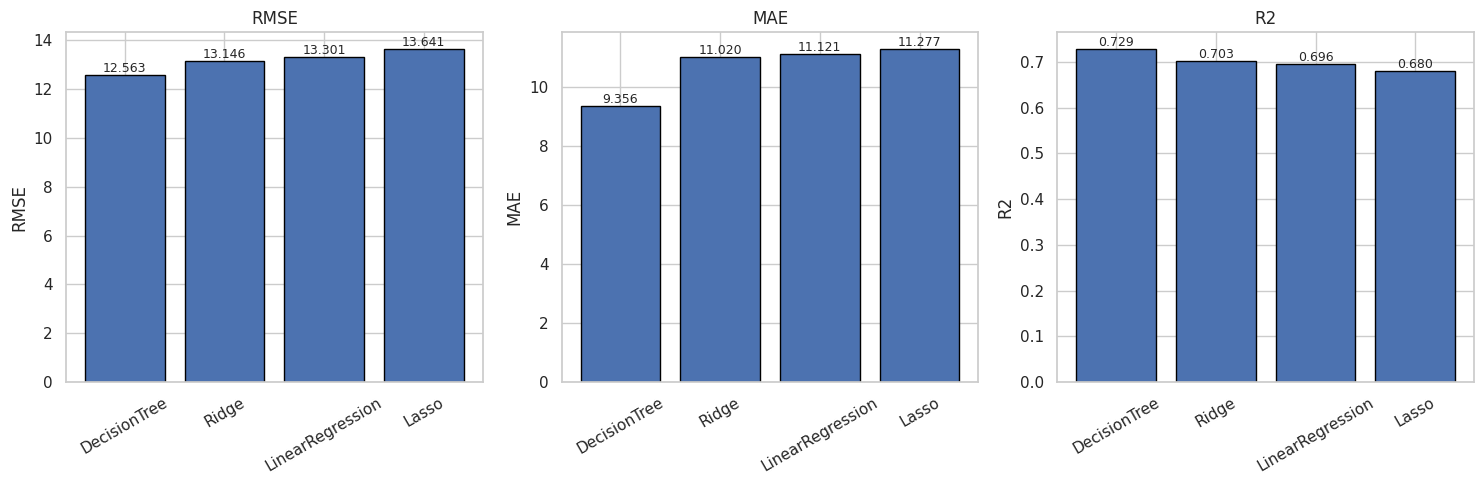

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    bars = ax.bar(results_df['Model'], results_df[metric], edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

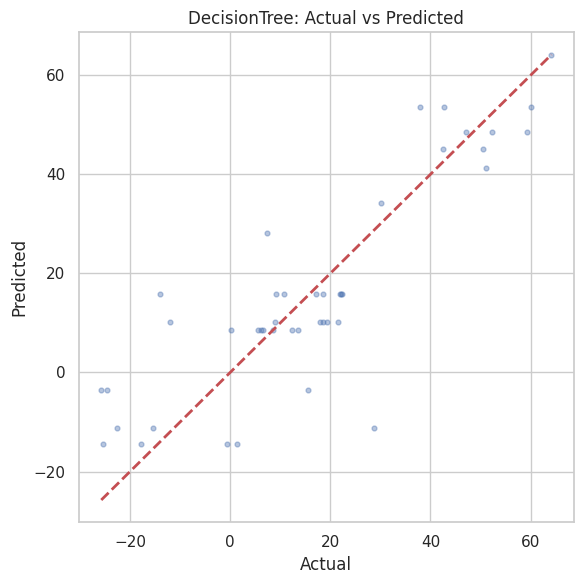

In [28]:
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]

if best_name in ('Ridge', 'Lasso', 'LinearRegression'):
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, s=12)
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
plt.plot([mn, mx], [mn, mx], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'{best_name}: Actual vs Predicted')
plt.tight_layout()
plt.show()

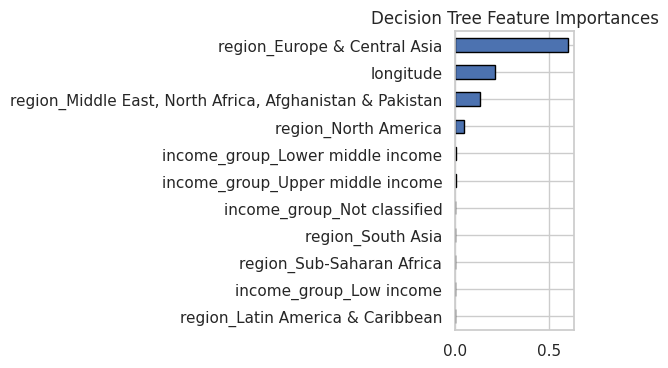

In [32]:
dt_model = models['DecisionTree']
feat_imp = pd.Series(dt_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)

plt.figure(figsize=(6, max(3, len(feat_imp) * 0.35)))
feat_imp.plot.barh(edgecolor='black')
plt.title('Decision Tree Feature Importances')
plt.tight_layout()
plt.show()

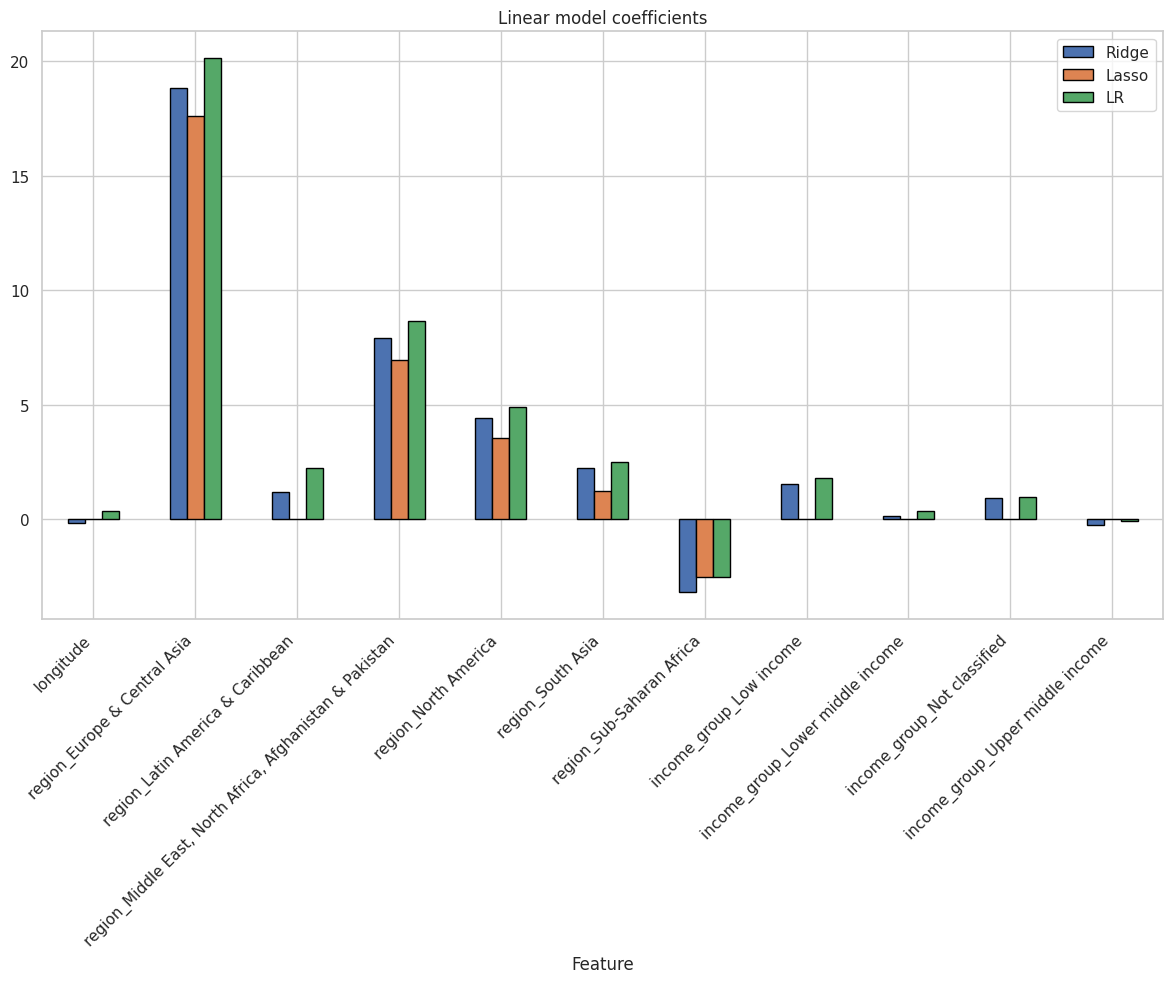

In [34]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Ridge': models['Ridge'].coef_,
    'Lasso': models['Lasso'].coef_,
    'LR': models['LinearRegression'].coef_,
})
coef_df = coef_df.set_index('Feature')
coef_df.plot.bar(figsize=(12, 10), edgecolor='black')
plt.title('Linear model coefficients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Сохраняем модель и скейлер
joblib.dump(best_model, 'best_regression_model.pkl')
if best_name in ('Ridge', 'Lasso', 'LinearRegression'):
    joblib.dump(scaler, 'regression_scaler.pkl')

print(f'Лучшая модель: {best_name}')
print(f'R2 = {results_df.iloc[0]["R2"]:.4f}')
print('Сохранено в best_regression_model.pkl')